In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class LoanState(TypedDict, total=False):
    age: int
    monthly_income: float
    loan_amount: float
    credit_score: int
    existing_debt: float
    employment_years: int

    monthly_income_processed: float
    loan_amount_processed: float
    existing_debt_processed: float

    credit_category: str
    debt_to_income_ratio: float
    income_stability_score: float

    risk_score: float
    risk_level: str

    # Final result
    decision: str

In [3]:
def validate_applicant(state: LoanState):
    print("\n--- Validating Applicant ---")
    if state["age"] < 18:
        raise ValueError("Applicant must be at least 18 years old.")
    if state["monthly_income"] <= 0:
        raise ValueError("Monthly income must be greater than 0.")
    if state["loan_amount"] <= 0:
        raise ValueError("Loan amount must be greater than 0.")
    if not 300 <= state["credit_score"] <= 850:
        raise ValueError("Credit score must be between 300 and 850.")
    if state["existing_debt"] < 0:
        raise ValueError("Existing debt cannot be negative.")
    if state["employment_years"] < 0:
        raise ValueError("Employment years cannot be negative.")
    print("Applicant data is valid.")
    return state

In [4]:
def preprocess_data(state: LoanState):
    print("\n--- Preprocessing Data ---")
    return {
        "monthly_income_processed": float(state["monthly_income"]),
        "loan_amount_processed": float(state["loan_amount"]),
        "existing_debt_processed": float(state["existing_debt"])
    }


In [5]:
def calculate_credit_category(state: LoanState):
    print("\n--- Calculating Credit Category ---")
    credit_score = state["credit_score"]
    if credit_score >= 750:
        category = "Excellent"
    elif credit_score >= 700:
        category = "Good"
    elif credit_score >= 650:
        category = "Fair"
    else:
        category = "Poor"
    return {
        "credit_category": category
    }

In [6]:
def calculate_dti(state: LoanState):
    print("\n--- Calculating Debt-to-Income Ratio ---")
    income = state["monthly_income_processed"]
    debt = state["existing_debt_processed"]
    dti = (debt / income) * 100
    return {
        "debt_to_income_ratio": round(dti, 2)
    }


In [7]:
def calculate_income_stability(state: LoanState):
    print("\n--- Calculating Income Stability ---")
    employment_years = state["employment_years"]
    if employment_years >= 5:
        score = 100
    elif employment_years >= 3:
        score = 80
    elif employment_years >= 1:
        score = 60
    else:
        score = 40
    return {
        "income_stability_score": score
    }

In [8]:
def calculate_risk(state: LoanState):
    print("\n--- Combining Results ---")
    credit_category = state["credit_category"]
    dti = state["debt_to_income_ratio"]
    income_stability = state["income_stability_score"]
    # Credit score component
    credit_points = {
        "Excellent": 10,
        "Good": 25,
        "Fair": 50,
        "Poor": 80
    }
    credit_risk = credit_points[credit_category]
    # DTI component
    if dti <= 20:
        dti_risk = 10
    elif dti <= 35:
        dti_risk = 30
    elif dti <= 50:
        dti_risk = 60
    else:
        dti_risk = 90
    # Income stability component
    stability_risk = 100 - income_stability
    # Overall risk score
    risk_score = (
        credit_risk * 0.4
        + dti_risk * 0.35
        + stability_risk * 0.25
    )
    risk_score = round(risk_score, 2)
    # Determine risk level
    if risk_score <= 30:
        risk_level = "Low"
    elif risk_score <= 60:
        risk_level = "Medium"
    else:
        risk_level = "High"
    print(f"Risk Score: {risk_score}")
    print(f"Risk Level: {risk_level}")
    return {
        "risk_score": risk_score,
        "risk_level": risk_level
    }

In [9]:
def decide_loan_route(state: LoanState):
    risk_level = state["risk_level"]
    if risk_level == "Low":
        return "approve"
    elif risk_level == "Medium":
        return "manual_review"
    else:
        return "reject"

In [10]:
def approve_loan(state: LoanState):
    print("\n--- Loan Approved ---")
    return {
        "decision": "Loan approved"
    }


In [ ]:
def manual_review(state: LoanState):
    print("\n--- Manual Review Required ---")
    return {
        "decision": "Loan sent for manual review"
    }

In [13]:
def reject_loan(state: LoanState):
    print("\n--- Loan Rejected ---")
    return {
        "decision": "Loan rejected"
    }


In [14]:
def generate_decision(state: LoanState):
    print("\n--- Final Loan Decision ---")
    print(f"Credit Category      : {state['credit_category']}")
    print(f"Debt-to-Income Ratio : {state['debt_to_income_ratio']}%")
    print(f"Income Stability     : {state['income_stability_score']}")
    print(f"Risk Score           : {state['risk_score']}")
    print(f"Risk Level           : {state['risk_level']}")
    print(f"Decision             : {state['decision']}")
    return state


In [15]:
graph = StateGraph(LoanState)


# Add nodes
graph.add_node("validate_applicant", validate_applicant)
graph.add_node("preprocess_data", preprocess_data)

graph.add_node("calculate_credit_category", calculate_credit_category)
graph.add_node("calculate_dti", calculate_dti)
graph.add_node("calculate_income_stability", calculate_income_stability)

graph.add_node("calculate_risk", calculate_risk)

graph.add_node("approve_loan", approve_loan)
graph.add_node("manual_review", manual_review)
graph.add_node("reject_loan", reject_loan)

graph.add_node("generate_decision", generate_decision)


In [16]:
graph.add_edge(START, "validate_applicant")
graph.add_edge("validate_applicant","preprocess_data")
graph.add_edge("preprocess_data","calculate_credit_category")
graph.add_edge("preprocess_data","calculate_dti")
graph.add_edge("preprocess_data","calculate_income_stability")
graph.add_edge("calculate_credit_category","calculate_risk")
graph.add_edge("calculate_dti","calculate_risk")
graph.add_edge("calculate_income_stability","calculate_risk")
graph.add_conditional_edges("calculate_risk",decide_loan_route,{
        "approve": "approve_loan",
        "manual_review": "manual_review",
        "reject": "reject_loan"
    })
graph.add_edge("approve_loan", "generate_decision")
graph.add_edge("manual_review", "generate_decision")
graph.add_edge("reject_loan", "generate_decision")
graph.add_edge("generate_decision", END)


In [17]:
app = graph.compile()

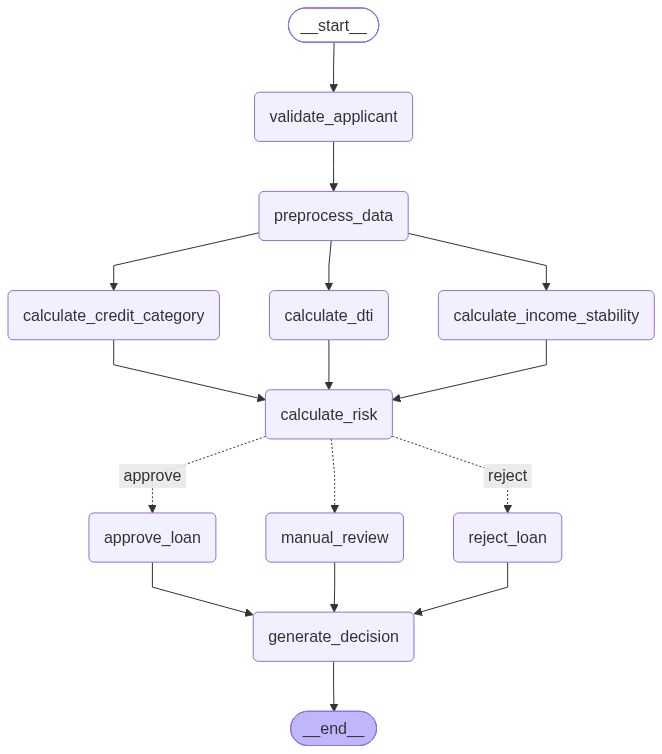

In [18]:
## workflow visualization

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
initial_state = {
    "age": 28,
    "monthly_income": 75000,
    "loan_amount": 500000,
    "credit_score": 760,
    "existing_debt": 100000,
    "employment_years": 4
}

In [20]:
final_result = app.invoke(initial_state)


--- Validating Applicant ---
Applicant data is valid.

--- Preprocessing Data ---

--- Calculating Credit Category ---

--- Calculating Debt-to-Income Ratio ---

--- Calculating Income Stability ---

--- Combining Results ---
Risk Score: 40.5
Risk Level: Medium

--- Manual Review Required ---

--- Final Loan Decision ---
Credit Category      : Excellent
Debt-to-Income Ratio : 133.33%
Income Stability     : 80
Risk Score           : 40.5
Risk Level           : Medium
Decision             : Loan sent for manual review
